##### 1. Introdução ao Pandas

In [2]:
!pip install -q -U watermark

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [5]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3



##### Estruturas de Dados - Series e DataFrames

- Uma série é uma estrutura de uma dimensão
- Um DataFrame é similar a uma tabela

In [6]:
# Criação da Serie
s = pd.Series([10, 20, 30, 40, 50], name = "Valores")

print(type(s))
print()
print(s)

<class 'pandas.core.series.Series'>

0    10
1    20
2    30
3    40
4    50
Name: Valores, dtype: int64


In [7]:
# Criação de um DataFrame

# 1. Cria-se um dicionário

dados = {
    "Nome": ["Ana", "Bruno", "Fabiana", "Ronaldo", "Eliana", "Matias"],
    "Idade": [28, 34, 29, 17, None, 78],
    "Cidade": ["Blumenau", "São Paulo", "Blumenau", "São Paulo", "Salvador", "São Paulo"],
    "Salário": [None, 7500, 6200, 9300, 8100, 15400]
}

# Convertendo para DataFrame

df = pd.DataFrame(dados)
df.head()

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


##### 2. Leitura e Escrita de Dados no formato CSV

In [8]:
# Salvando (Escrevendo) o DataFrame em um arquivo CSV

# index = False evita que o índice do DataFrame seja salvo como uma coluna no CSV
df.to_csv("Dados.csv", index=False, encoding="utf-8")

In [9]:
# Incluindo o índice
df.to_csv("Dados_Com_Indice.csv", index=True, encoding="utf-8")

In [10]:
# Lendo Arquivos CSV
df_read_csv = pd.read_csv("Dados_Com_Indice.csv")
df_read_csv.head()

,Unnamed: 0,Nome,Idade,Cidade,Salário
0,0,Ana,28.0,Blumenau,NaN
1,1,Bruno,34.0,São Paulo,7500.0
2,2,Fabiana,29.0,Blumenau,6200.0
3,3,Ronaldo,17.0,São Paulo,9300.0
4,4,Eliana,NaN,Salvador,8100.0


In [11]:
# Deletando a coluna de índice 0

df_read_csv.drop(df_read_csv.columns[0], axis=1)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


##### 3. Seleção e Indexação com Pandas

In [12]:
# Visualizando as primeiras linhas
df.head()

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


In [13]:
# Selecionando uma unica coluna do DataFrame

name = df["Nome"]
name.head()

0        Ana
1      Bruno
2    Fabiana
3    Ronaldo
4     Eliana
Name: Nome, dtype: object

In [14]:
# Selecionando mais de uma coluna

info_pessoal = df[["Nome", "Cidade"]]
info_pessoal.head()

,Nome,Cidade
0,Ana,Blumenau
1,Bruno,São Paulo
2,Fabiana,Blumenau
3,Ronaldo,São Paulo
4,Eliana,Salvador


##### loc e iloc

O loc é usado com a combinação de um índice (referente à linha) e uma coluna ou conjunto de colunas

In [15]:
nome = df.loc[1, ["Nome", "Cidade"]]
nome.head()

Nome          Bruno
Cidade    São Paulo
Name: 1, dtype: object

O iloc usa um par com o índice da linha e um índice da coluna, ele não contabiliza a coluna de índices

In [16]:
dados_fabi = df.iloc[2, [0, 1, 2, 3]]
print(df)
print()
print(dados_fabi)

      Nome  Idade     Cidade  Salário
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6200.0
3  Ronaldo   17.0  São Paulo   9300.0
4   Eliana    NaN   Salvador   8100.0
5   Matias   78.0  São Paulo  15400.0

Nome        Fabiana
Idade          29.0
Cidade     Blumenau
Salário      6200.0
Name: 2, dtype: object


In [17]:
# Selecionando um intervalo de linhas e todas as colunas

# Os fatiamentos para iloc e loc são diferentes, o loc é inclusivo, o iloc é exclusivo

all_columns_1_3_lines = df.iloc[1:3]
all_columns_1_3_lines.head()

,Nome,Idade,Cidade,Salário
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0


##### Filtragem de Dados

Você pode filtrar linhas com base em condições lógicas, de forma muito intuitiva, bem coo usar colunas com índice.

In [18]:
df.head(5)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


In [19]:
df = df.set_index(df.columns[0])
df.head(5)

,Idade,Cidade,Salário
Nome,,,
Ana,28.0,Blumenau,NaN
Bruno,34.0,São Paulo,7500.0
Fabiana,29.0,Blumenau,6200.0
Ronaldo,17.0,São Paulo,9300.0
Eliana,NaN,Salvador,8100.0


In [20]:
df.loc[["Fabiana"], ["Salário"]]

,Salário
Nome,
Fabiana,6200.0


In [21]:
df = df.reset_index()
df.head()

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0


Filtrando o próprio dataframe

In [22]:
mais_de_30 = df[(df["Idade"] > 30) & (df["Salário"] > 10_000)]
print(mais_de_30)

     Nome  Idade     Cidade  Salário
5  Matias   78.0  São Paulo  15400.0


Filtragem com várias condições

In [23]:
sp_salario_alto = df[(df["Cidade"] == "São Paulo") & (df["Salário"] >= 5_000)]
print(sp_salario_alto)

      Nome  Idade     Cidade  Salário
1    Bruno   34.0  São Paulo   7500.0
3  Ronaldo   17.0  São Paulo   9300.0
5   Matias   78.0  São Paulo  15400.0


Verificação da existência de células com valores nulos

In [24]:
print(df.isnull())

    Nome  Idade  Cidade  Salário
0  False  False   False     True
1  False  False   False    False
2  False  False   False    False
3  False  False   False    False
4  False   True   False    False
5  False  False   False    False


In [25]:
# Verificando se existe qualquer valor nulo
print(df.isnull().any())

Nome       False
Idade       True
Cidade     False
Salário     True
dtype: bool


In [26]:
# Retornando as colunas que tem pelo menos um valor nulo
df_col_null = df.loc[:, df.isnull().any()]
df_col_null.head()

,Idade,Salário
0,28.0,NaN
1,34.0,7500.0
2,29.0,6200.0
3,17.0,9300.0
4,NaN,8100.0


In [27]:
# Linhas com valores ausentes
df_linhas_null = df[df.isnull().any(axis=1)]
df_linhas_null.head()

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
4,Eliana,NaN,Salvador,8100.0


In [28]:
# Filtrando pela coluna
linhas_com_idade_nula = df[df["Idade"].isnull()]
linhas_com_idade_nula.head()

,Nome,Idade,Cidade,Salário
4,Eliana,NaN,Salvador,8100.0


##### Inspeção do DataFrame

Podemos inspecionar e resumir um dataframe de várias formas

In [29]:
# Dimensões do DataFrame
print(df.shape)

(6, 4)


In [30]:
df.head(3)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0


In [31]:
df.tail(3)

,Nome,Idade,Cidade,Salário
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [32]:
# Obtendo informações com info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Nome     6 non-null      object 
 1   Idade    5 non-null      float64
 2   Cidade   6 non-null      object 
 3   Salário  5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes
None


In [33]:
print(df.describe(include = "all"))

       Nome      Idade     Cidade       Salário
count     6   5.000000          6      5.000000
unique    6        NaN          3           NaN
top     Ana        NaN  São Paulo           NaN
freq      1        NaN          3           NaN
mean    NaN  37.200000        NaN   9300.000000
std     NaN  23.636836        NaN   3588.175024
min     NaN  17.000000        NaN   6200.000000
25%     NaN  28.000000        NaN   7500.000000
50%     NaN  29.000000        NaN   8100.000000
75%     NaN  34.000000        NaN   9300.000000
max     NaN  78.000000        NaN  15400.000000


##### Operações e Transformações de Dados com Pandas

In [36]:
# Criação de Coluna

df["Salário Atual"] = df["Salário"] * 12
print(df)

      Nome  Idade     Cidade  Salário  Salário Atual
0      Ana   28.0   Blumenau      NaN            NaN
1    Bruno   34.0  São Paulo   7500.0        90000.0
2  Fabiana   29.0   Blumenau   6200.0        74400.0
3  Ronaldo   17.0  São Paulo   9300.0       111600.0
4   Eliana    NaN   Salvador   8100.0        97200.0
5   Matias   78.0  São Paulo  15400.0       184800.0


In [37]:
df["Bônus"] = df["Salário"].apply(lambda x: x * 0.10 if x > 7000 else x * 0.05)
print(df)

      Nome  Idade     Cidade  Salário  Salário Atual   Bônus
0      Ana   28.0   Blumenau      NaN            NaN     NaN
1    Bruno   34.0  São Paulo   7500.0        90000.0   750.0
2  Fabiana   29.0   Blumenau   6200.0        74400.0   310.0
3  Ronaldo   17.0  São Paulo   9300.0       111600.0   930.0
4   Eliana    NaN   Salvador   8100.0        97200.0   810.0
5   Matias   78.0  São Paulo  15400.0       184800.0  1540.0


In [48]:
df["Teste"] = "x"
#df.head()
df.drop(columns=["Teste"], inplace=True)
df.head()

,Nome,Idade,Cidade,Salário,Salário Atual,Bônus
0,Ana,28.0,Blumenau,NaN,NaN,NaN
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0
2,Fabiana,29.0,Blumenau,6200.0,74400.0,310.0
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0


In [50]:
# Criação de uma lista de condições

condicoes = [

    df["Idade"] < 10,
    (df["Idade"] >= 10) & (df["Idade"] <= 30),
    (df["Idade"] > 30) & (df["Idade"] <= 50),
    df["Idade"] > 50

]
print(condicoes)

[0    False
1    False
2    False
3    False
4    False
5    False
Name: Idade, dtype: bool, 0     True
1    False
2     True
3     True
4    False
5    False
Name: Idade, dtype: bool, 0    False
1     True
2    False
3    False
4    False
5    False
Name: Idade, dtype: bool, 0    False
1    False
2    False
3    False
4    False
5     True
Name: Idade, dtype: bool]


In [52]:
# Define os rótulos correspondentes
faixas = ["Menor de Idade", "Jovem", "Adulto", "Idoso"]
df["Faixa Etária"] = np.select(condicoes, faixas, default="Idade Não Informada")

df.head()

,Nome,Idade,Cidade,Salário,Salário Atual,Bônus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6200.0,74400.0,310.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Jovem
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0,Idade Não Informada


##### Agrupamento de Dados (Group By) com Pandas

O método groupby é extremamente poderoso para análises segmentadas. É exatamente o mesmo conceito usado em linguagem SQL.

In [54]:
df.head()

,Nome,Idade,Cidade,Salário,Salário Atual,Bônus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6200.0,74400.0,310.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Jovem
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0,Idade Não Informada


In [ ]:
# Agrupando os dados por "Cidade" e calculando a média de "Salario" para cada cidade

media_salario_cidade = df.groupby("Cidade")["Salário"].mean()
print(media_salario_cidade)

Cidade
Blumenau      6200.000000
Salvador      8100.000000
São Paulo    10733.333333
Name: Salário, dtype: float64


In [63]:
# Agrupando por cidade e calculando múltiplas agregações

agregacoes_cidade = df.groupby("Cidade").agg(Media_Salarial = ("Salário", "mean"), 
                                             Idade_Maxima = ("Idade", "max"),
                                             Contagem = ("Nome", "count"))


print(agregacoes_cidade)

           Media_Salarial  Idade_Maxima  Contagem
Cidade                                           
Blumenau      6200.000000          29.0         2
Salvador      8100.000000           NaN         1
São Paulo    10733.333333          78.0         3


##### Manipulação de Tipos de Dados

In [65]:
print(df.dtypes)
df.head()

Nome              object
Idade            float64
Cidade            object
Salário          float64
Salário Atual    float64
Bônus            float64
Faixa Etária      object
dtype: object


,Nome,Idade,Cidade,Salário,Salário Atual,Bônus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6200.0,74400.0,310.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Jovem
4,Eliana,NaN,Salvador,8100.0,97200.0,810.0,Idade Não Informada


In [66]:
df = df.dropna(subset=["Idade"])
df.head()

,Nome,Idade,Cidade,Salário,Salário Atual,Bônus,Faixa Etária
0,Ana,28.0,Blumenau,NaN,NaN,NaN,Jovem
1,Bruno,34.0,São Paulo,7500.0,90000.0,750.0,Adulto
2,Fabiana,29.0,Blumenau,6200.0,74400.0,310.0,Jovem
3,Ronaldo,17.0,São Paulo,9300.0,111600.0,930.0,Jovem
5,Matias,78.0,São Paulo,15400.0,184800.0,1540.0,Idoso


In [75]:
# Convertendo a idade de float para int
df["Idade"] = df["Idade"].astype(int)
#df.head()
#print(df.dtypes)

C:\Users\josue\AppData\Local\Temp\ipykernel_11528\2004996703.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Idade"] = df["Idade"].astype(int)


In [84]:
# Convertendo o tipo object para string

df["Nome"] = df["Nome"].astype("string")
df["Cidade"] = df["Cidade"].astype("string")
#df["Faixa Etária"] = df["Faixa Etária"].astype("string")

print(df.dtypes)

Nome             string[python]
Idade                     int64
Cidade           string[python]
Salário                 float64
Salário Atual           float64
Bônus                   float64
Faixa Etária             object
dtype: object


C:\Users\josue\AppData\Local\Temp\ipykernel_11528\2658829757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Nome"] = df["Nome"].astype("string")
C:\Users\josue\AppData\Local\Temp\ipykernel_11528\2658829757.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cidade"] = df["Cidade"].astype("string")


In [87]:
df["Faixa Etária"] = df["Faixa Etária"].apply(lambda x: x.upper())
df.head()

C:\Users\josue\AppData\Local\Temp\ipykernel_11528\4294903174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Faixa Etária"] = df["Faixa Etária"].apply(lambda x: x.upper())


,Nome,Idade,Cidade,Salário,Salário Atual,Bônus,Faixa Etária
0,Ana,28,Blumenau,NaN,NaN,NaN,JOVEM
1,Bruno,34,São Paulo,7500.0,90000.0,750.0,ADULTO
2,Fabiana,29,Blumenau,6200.0,74400.0,310.0,JOVEM
3,Ronaldo,17,São Paulo,9300.0,111600.0,930.0,JOVEM
5,Matias,78,São Paulo,15400.0,184800.0,1540.0,IDOSO


In [88]:
# Fazendo a mesma coisa com compressão de dicionários

df = df.astype({col: "string" for col in df.select_dtypes(include="object").columns})

##### Criação de Tabelas Dinâmicas

Tabelas dinâmicas (Pivot Tables) são ótimas para resumir dados de forma semelhante a uma planilha.

In [89]:
dados_vendas = {

    "Data": pd.to_datetime(["2026-09-01", "2026-09-01", "2026-09-02", "2026-09-02", "2026-09-01"]),
    "Região": ["Norte", "Sul", "Norte", "Sul", "Norte"],
    "Vendedor": ["Carlos", "Ana", "Carlos", "Ana", "Pedro"],
    "Vendas": [250, 300, 150, 400, 200]

}

In [90]:
df_vendas = pd.DataFrame(dados_vendas)

In [91]:
df_vendas

,Data,Região,Vendedor,Vendas
0,2026-09-01,Norte,Carlos,250
1,2026-09-01,Sul,Ana,300
2,2026-09-02,Norte,Carlos,150
3,2026-09-02,Sul,Ana,400
4,2026-09-01,Norte,Pedro,200


In [92]:
# Criando a tabela dinâmica

pivot_table = df_vendas.pivot_table(values = "Vendas",
                                    index = "Região",
                                    columns="Vendedor",
                                    aggfunc="sum",
                                    fill_value=0)

In [93]:
pivot_table

Vendedor,Ana,Carlos,Pedro
Região,,,
Norte,0,400,200
Sul,700,0,0


##### Visualização de Dados com Pandas e Matplotlib

In [94]:
# É uma oa prática executar este comando em notebooks Jupyter
# para garantir ue os gráficos apareçam inline

%matplotlib inline

In [95]:
df_funcionarios = pd.read_csv("Dados.csv")

In [96]:
media_salario_cidade = df_funcionarios.groupby("Cidade")["Salário"].mean()

In [97]:
print(type(media_salario_cidade))

<class 'pandas.core.series.Series'>


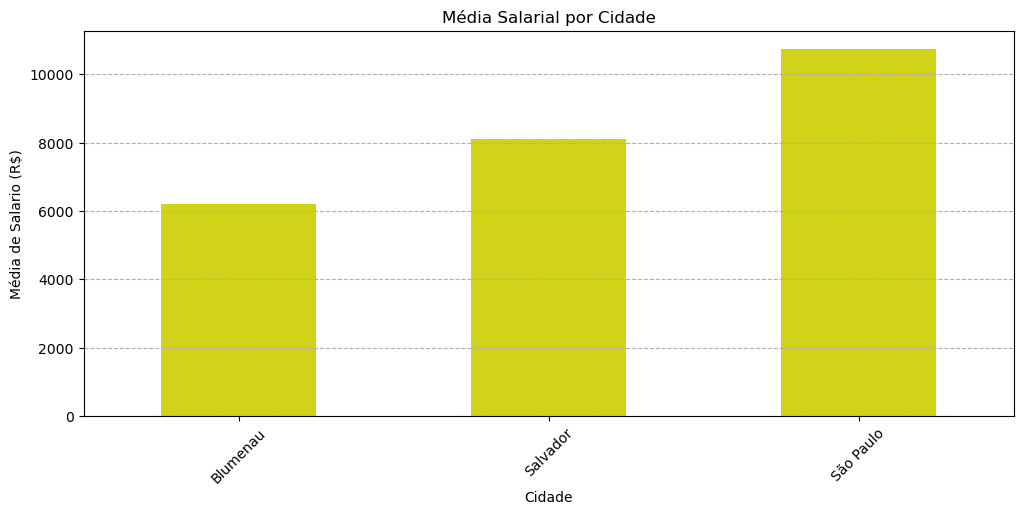

In [100]:
# Criando um gráfico de barra para média de salários por cidade

# O Series do Pandas tem o método plot que chama o matplotlib
media_salario_cidade.plot(kind="bar", figsize=(12, 5), color="#D0D317")

# Adicionando configurações ao gráfico
# Titulo do Gráfico
plt.title("Média Salarial por Cidade")
# Eixo X
plt.xlabel("Cidade")
# Eixo Y
plt.ylabel("Média de Salario (R$)")
# Rotação de legenda eixo X
plt.xticks(rotation=45)
# Configurações do Grid
plt.grid(axis="y", linestyle="--")

# Mostra o gráfico
plt.show()

In [107]:
# Contagem de registros (funcionários) por cidade
contagem_cidade = df_funcionarios["Cidade"].value_counts()
print(type(contagem_cidade))

<class 'pandas.core.series.Series'>


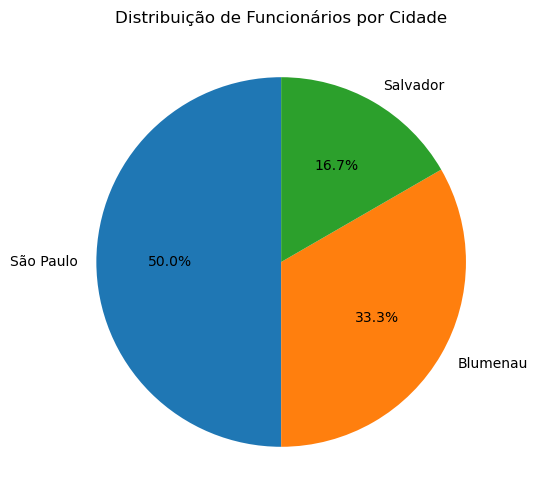

In [108]:
contagem_cidade.plot(kind = "pie", autopct = "%1.1f%%", figsize=(6, 6), startangle=90)
plt.title("Distribuição de Funcionários por Cidade")
plt.ylabel('') # Remove o rótulo do eixo y
plt.show()